In [1]:
import numpy as np; import datasets

import datasets

# Indica el formato 'csv' y luego la ruta al archivo
ds = datasets.load_dataset("csv", data_files="bd_student_performance.csv")
print(ds)


DatasetDict({
    train: Dataset({
        features: ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade'],
        num_rows: 14003
    })
})


In [8]:
import pandas as pd; df = ds['train'].to_pandas()
from sklearn.preprocessing import StandardScaler; from sklearn.model_selection import train_test_split

#Escojo las filas con las que quiero hacer mi modelo
#columnas_interes = ['StressLevel', 'StudyHours', 'Attendance']
#X = df[columnas_interes]
y = df.pop('ExamScore'); X = df; df.info()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=23)
scaler = StandardScaler(); X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test);

<class 'pandas.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  EduTech               14003 non-null  int64
 13  StressLevel           14003 non-null  int64
 14  FinalGrade            14003 non-null  int64
dtypes: int64(15)
memory usage: 1.6 MB


In [9]:
from sklearn.linear_model import LinearRegression; from sklearn.metrics import r2_score
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train); y_test_pred = linreg.predict(X_test)
r2_train = r2_score(y_train, y_train_pred); r2_test = r2_score(y_test, y_test_pred)

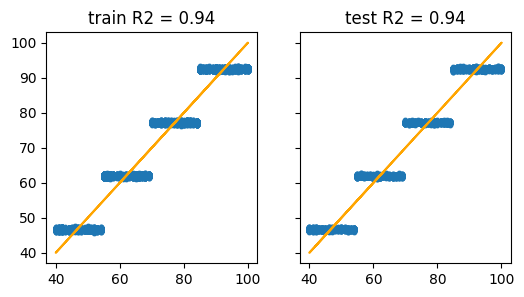

In [10]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey = 'all')
ax = axs[0]; ax.set_title(f'train R2 = {r2_train:.2f}')
ax.scatter(y_train, y_train_pred, s=10); ax.plot(y_train, y_train, color='orange')
ax = axs[1]; ax.set_title(f'test R2 = {r2_test:.2f}')
ax.scatter(y_test, y_test_pred, s=10); ax.plot(y_test, y_test, color='orange')


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(2); X_train = poly.fit_transform(X_train); X_test = poly.transform(X_test)
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train); y_test_pred = linreg.predict(X_test)
r2_train = r2_score(y_train, y_train_pred); r2_test = r2_score(y_test, y_test_pred)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey = 'all')
ax = axs[0]; ax.set_title(f'train R2 = {r2_train:.2f}')
ax.scatter(y_train, y_train_pred, s=10); ax.plot(y_train, y_train, color='orange')
ax = axs[1]; ax.set_title(f'test R2 = {r2_test:.2f}')
ax.scatter(y_test, y_test_pred, s=10); ax.plot(y_test, y_test, color='orange');